# COMPREHENSIVE AIR QUALITY DATA EXPLORATION

Inspired by the 'Comprehensive Data Exploration with Python' notebook, this analysis focuses on Nairobi air quality sensor data.

**Our Factor of Concern (Dependent Variable): `pm25` (PM2.5)**
PM2.5 is the primary pollutant metric used by WHO/EPA for health risk classification. We will explore how other sensor readings (CO, CO2, temperature, humidity, VOC, NOx) relate to it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Load the data
df = pd.read_csv('aqmrg_relay_data_20260308_234216.csv')

# Check columns
df.columns

Index(['ID', 'Timestamp (EAT)', 'Device ID', 'PM1', 'PM2.5', 'PM10', 'CO',
       'CO2', 'Temperature', 'Humidity', 'VOC Index', 'NOx Index', 'Latitude',
       'Longitude'],
      dtype='str')

## 1. Univariate study: Analysing 'pm25'

In [2]:
# descriptive statistics summary
df['PM2.5'].describe()

count     1227.000000
mean        77.875143
std       1243.994132
min          0.000000
25%         36.000000
50%         36.000000
75%         36.000000
max      43611.000000
Name: PM2.5, dtype: float64

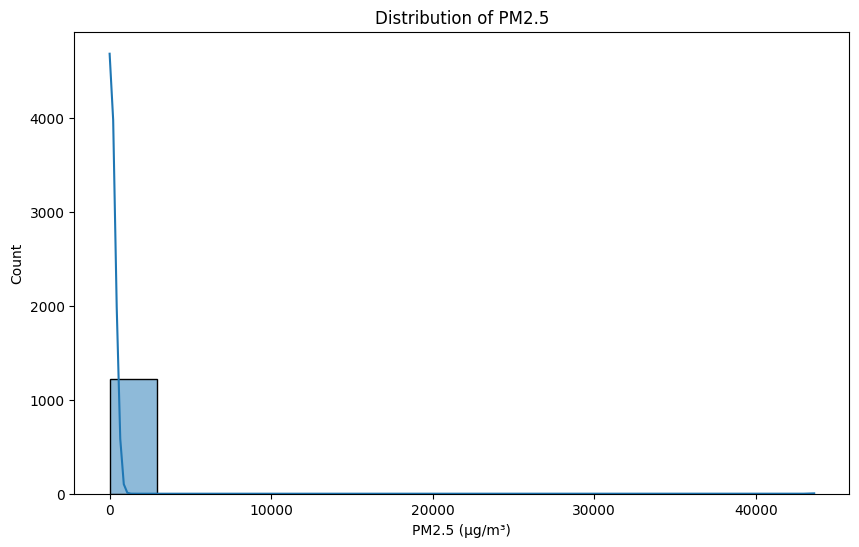

In [3]:
# histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['PM2.5'].dropna(), kde=True, bins=15)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 (µg/m³)')
plt.show()

In [4]:
# skewness and kurtosis
print("Skewness: %f" % df['PM2.5'].skew())
print("Kurtosis: %f" % df['PM2.5'].kurt())

Skewness: 35.012426
Kurtosis: 1226.244852


## 2. Multivariate study: PM2.5 vs Other Variables

Let's look at how PM2.5 correlates with other sensor readings (PM10, CO2, VOC, Temperature, Humidity).

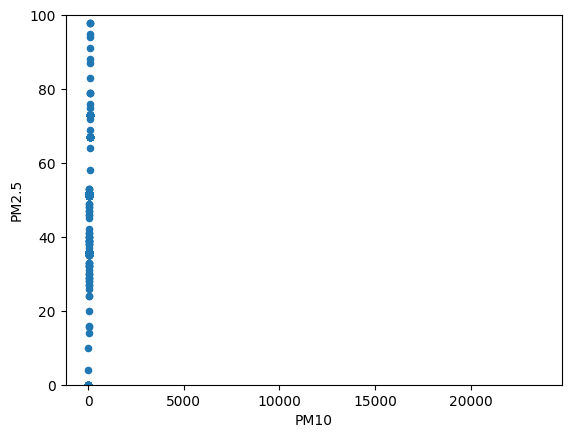

In [5]:
# scatter plot pm25/pm10
var = 'PM10'
data = pd.concat([df['PM2.5'], df[var]], axis=1)
data.plot.scatter(x=var, y='PM2.5', ylim=(0, 100));

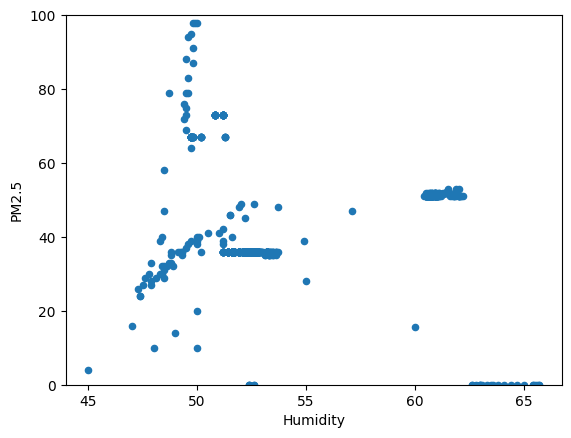

In [6]:
# scatter plot pm25/humidity
var = 'Humidity'
data = pd.concat([df['PM2.5'], df[var]], axis=1)
data.plot.scatter(x=var, y='PM2.5', ylim=(0, 100));

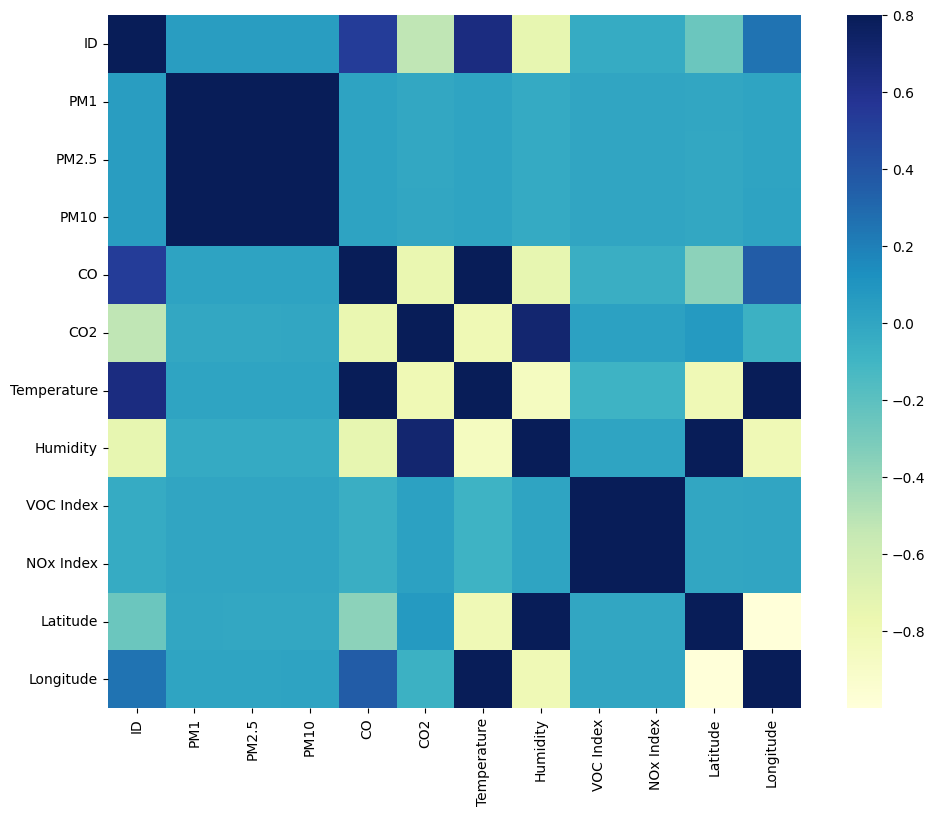

In [7]:
# correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corrmat = numeric_df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True, cmap="YlGnBu", annot=False);

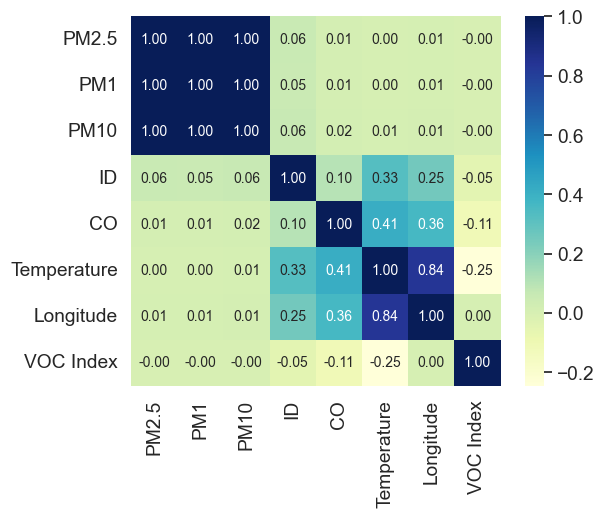

In [8]:
# pm25 correlation matrix (zoomed in)
k = 8 #number of variables for heatmap
cols = corrmat.nlargest(k, 'PM2.5')['PM2.5'].index
cm = np.corrcoef(df[cols].dropna().values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values, cmap="YlGnBu")
plt.show()

## 3. Missing Data Analysis
Important questions when thinking about missing data:
- How prevalent is the missing data?
- Is missing data random or does it have a pattern?

In [9]:
# missing data
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(10)

,Total,Percent
Latitude,174,0.141809
Longitude,174,0.141809
PM1,4,0.003260
CO,4,0.003260
VOC Index,4,0.003260
NOx Index,4,0.003260
PM10,3,0.002445
CO2,2,0.001630
Temperature,2,0.001630
Humidity,2,0.001630


## 4. Pairplot Analysis

To understand multivariate relationships globally, we use a pairplot.

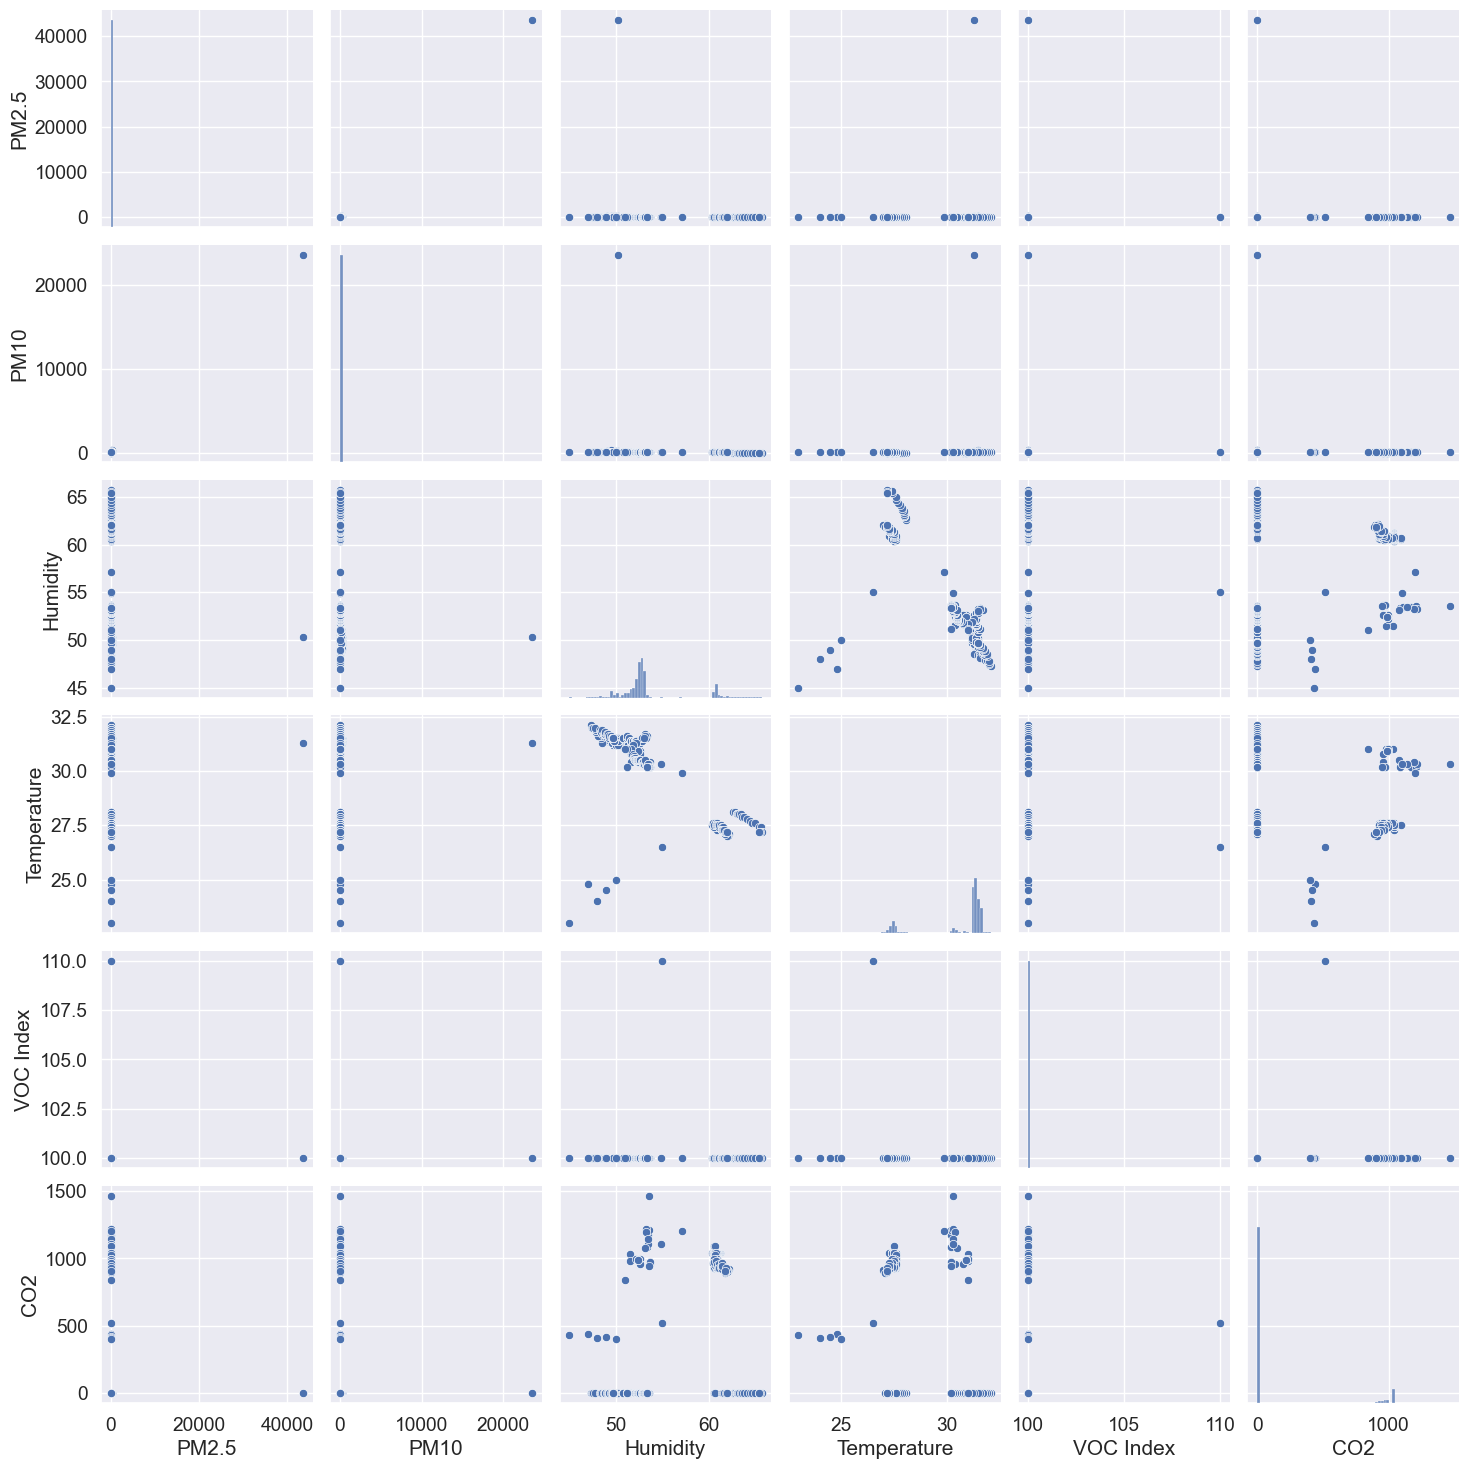

In [10]:
sns.pairplot(df[['PM2.5', 'PM10', 'Humidity', 'Temperature', 'VOC Index', 'CO2']].dropna(), size=2.5)
plt.show()

## 5. Bivariate Outlier Analysis

Identifying extreme outliers visually. Let's look at PM2.5 vs VOC and Temperature.

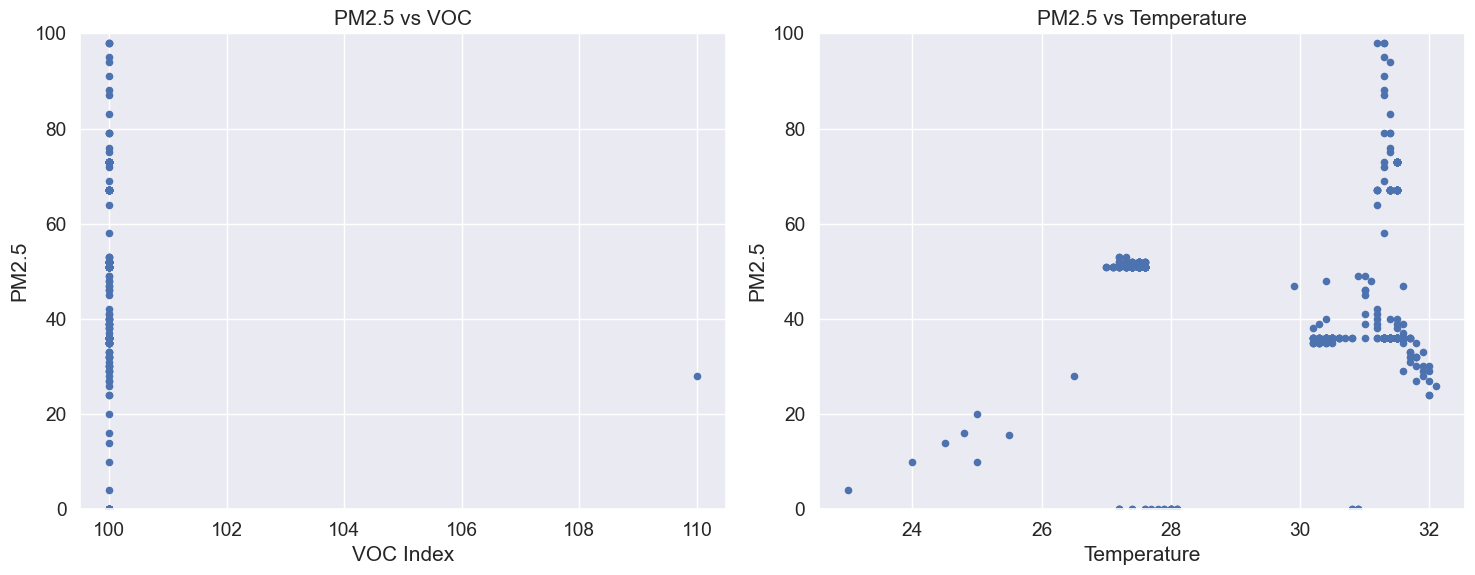

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

data_voc = pd.concat([df['PM2.5'], df['VOC Index']], axis=1)
data_voc.plot.scatter(x='VOC Index', y='PM2.5', ax=axes[0], ylim=(0, 100))
axes[0].set_title('PM2.5 vs VOC')

data_temp = pd.concat([df['PM2.5'], df['Temperature']], axis=1)
data_temp.plot.scatter(x='Temperature', y='PM2.5', ax=axes[1], ylim=(0, 100))
axes[1].set_title('PM2.5 vs Temperature')

plt.tight_layout()
plt.show()

## 6. Statistical Assumptions Testing (Normality)

Checking if PM2.5 follows a normal distribution.

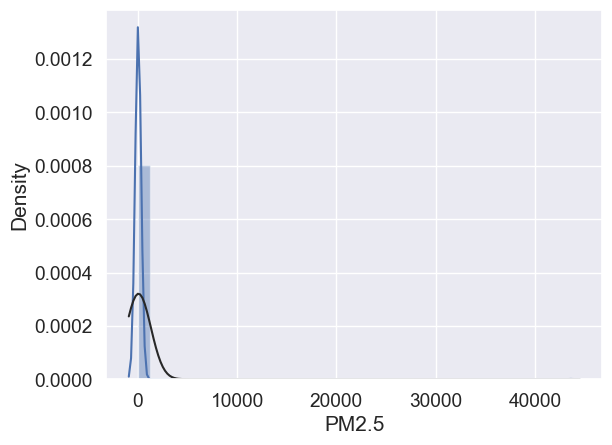

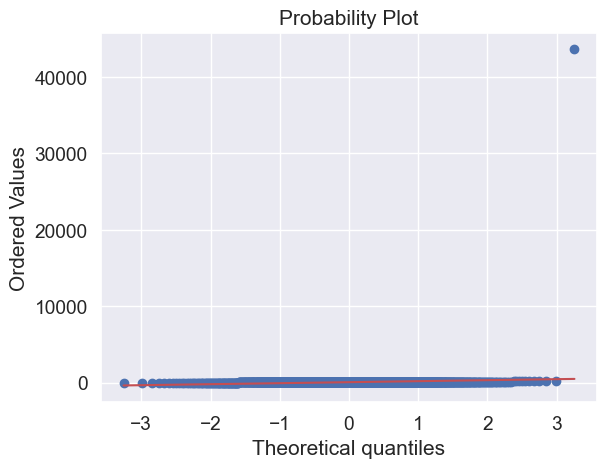

In [12]:
sns.distplot(df['PM2.5'].dropna(), fit=norm);
fig = plt.figure()
res = stats.probplot(df['PM2.5'].dropna(), plot=plt)

## 7. Skewness Correction & Homoscedasticity

Applying a log transformation to correct positive skewness. We use `np.log1p` (log(1+x)) to handle any zero values gracefully.

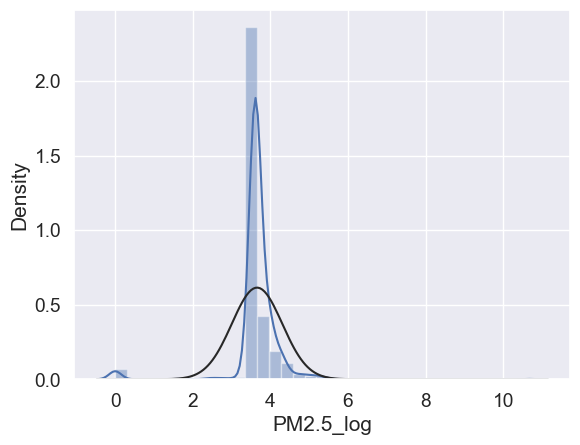

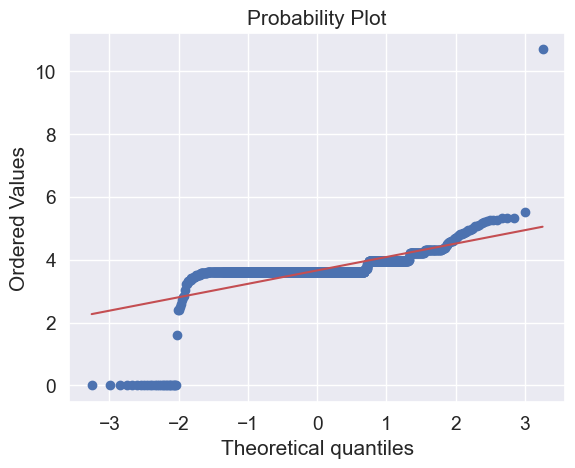

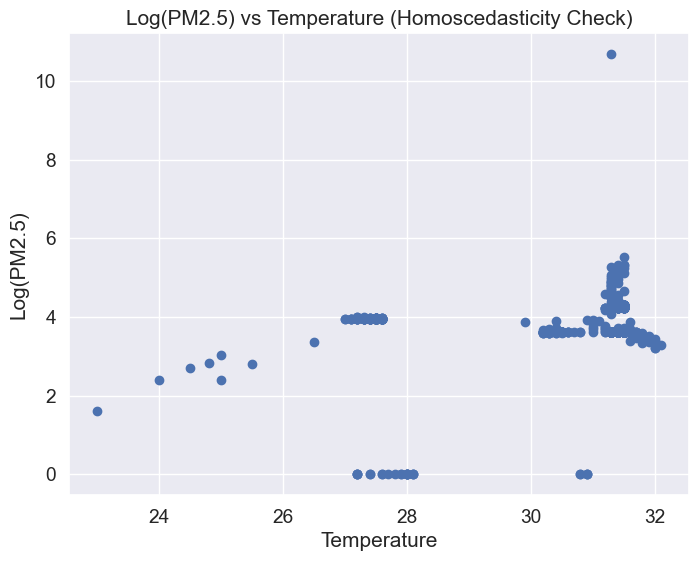

In [13]:
# Applying log transformation (log(1+x))
df['PM2.5_log'] = np.log1p(df['PM2.5'])

# Transformed histogram and normal probability plot
sns.distplot(df['PM2.5_log'].dropna(), fit=norm);
fig = plt.figure()
res = stats.probplot(df['PM2.5_log'].dropna(), plot=plt)

# Checking homoscedasticity with Temperature
plt.figure(figsize=(8, 6))
plt.scatter(df['Temperature'], df['PM2.5_log'])
plt.title('Log(PM2.5) vs Temperature (Homoscedasticity Check)')
plt.xlabel('Temperature')
plt.ylabel('Log(PM2.5)')
plt.show()